In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Upload file
from google.colab import files
uploaded = files.upload() # Click and select cardiovascular_disease.csv

Saving cardiovascular_diseases_dv3.csv to cardiovascular_diseases_dv3.csv


In [2]:
# sep=';' because your data is separated by semicolons
df = pd.read_csv('cardiovascular_diseases_dv3.csv', sep=';')

print("Shape:", df.shape)
print(df.head())

# Check column names. In your file last column is CARDIO_DISEASE
df.columns = ['age', 'gender', 'height', 'weight', 'ap_high', 'ap_low',
              'cholesterol', 'glucose', 'smoke', 'alcohol', 'physical_activity', 'cardio']

# 1. Convert age from days to years
df['age'] = (df['age'] / 365).round(0)

# 2. All data is already numeric, just check for missing
df = df.fillna(df.median())
df = df.astype(int)

print("\nCleaned Data:")
print(df.info())

Shape: (68783, 12)
   AGE  GENDER  HEIGHT  WEIGHT  AP_HIGH  AP_LOW  CHOLESTEROL  GLUCOSE  SMOKE  \
0   50       2     168      62      110      80            1        1      0   
1   55       1     156      85      140      90            3        1      0   
2   52       1     165      64      130      70            3        1      0   
3   48       2     169      82      150     100            1        1      0   
4   48       1     156      56      100      60            1        1      0   

   ALCOHOL  PHYSICAL_ACTIVITY  CARDIO_DISEASE  
0        0                  1               0  
1        0                  1               1  
2        0                  0               1  
3        0                  1               1  
4        0                  0               0  

Cleaned Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68783 entries, 0 to 68782
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  --

In [3]:
X = df.drop('cardio', axis=1) # features
y = df['cardio'] # target: 0 = No disease, 1 = Disease

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data split done")

Data split done


Logistic Regression Accuracy: 0.7262
KNN Accuracy: 0.6821
SVM Accuracy: 0.7281
Decision Tree Accuracy: 0.6363
Random Forest Accuracy: 0.6867

🏆 Best Model: SVM


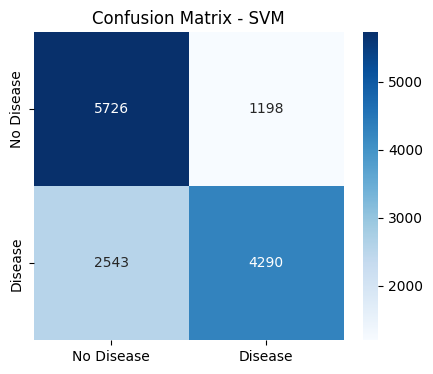


Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.83      0.75      6924
           1       0.78      0.63      0.70      6833

    accuracy                           0.73     13757
   macro avg       0.74      0.73      0.73     13757
weighted avg       0.74      0.73      0.73     13757



In [4]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# Best Model Confusion Matrix
best_model_name = max(results, key=results.get)
print(f"\n🏆 Best Model: {best_model_name}")

best_model = models[best_model_name]
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

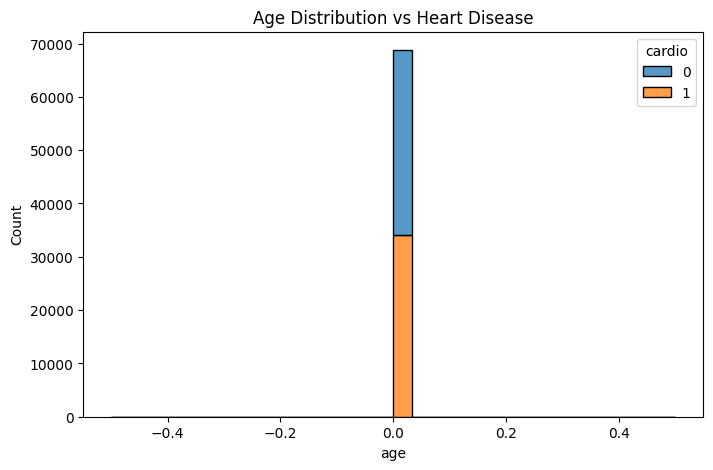

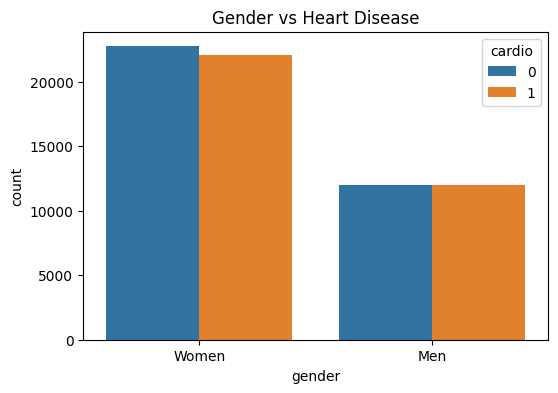

In [5]:
# 1. Age distribution by Disease
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue='cardio', multiple='stack', bins=30)
plt.title('Age Distribution vs Heart Disease')
plt.show()

# 2. Gender vs Disease Count
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='cardio', data=df)
plt.title('Gender vs Heart Disease')
plt.xticks([0,1], ['Women', 'Men'])
plt.show()

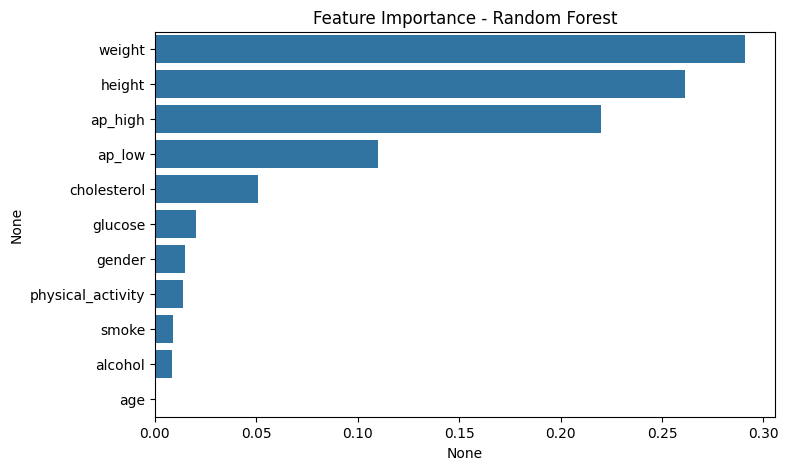

In [6]:
# Use Random Forest specifically for feature importance
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

importances = rf_model.feature_importances_
feat_names = X.columns
feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=feat_imp, y=feat_imp.index)
plt.title('Feature Importance - Random Forest')
plt.show()

In [7]:
results_df = pd.DataFrame(results.items(), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False)
print(results_df)
print("\nBest Model:", results_df.iloc[0]['Model'])

                 Model  Accuracy
2                  SVM  0.728066
0  Logistic Regression  0.726176
4        Random Forest  0.686705
1                  KNN  0.682053
3        Decision Tree  0.636258

Best Model: SVM


/tmp/ipykernel_721/3807517416.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp, y=feat_imp.index, palette='viridis')


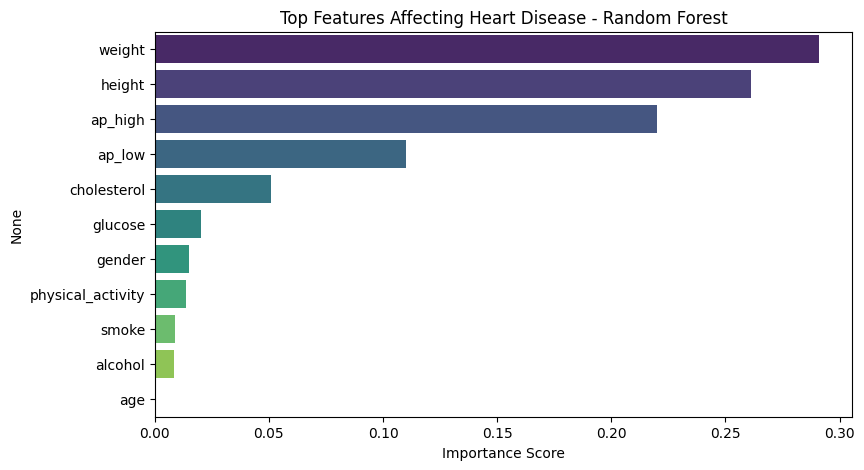

In [8]:
# Plot Feature Importance using Random Forest
rf_for_plot = RandomForestClassifier(random_state=42)
rf_for_plot.fit(X_train, y_train)

importances = rf_for_plot.feature_importances_
feat_names = X.columns
feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(x=feat_imp, y=feat_imp.index, palette='viridis')
plt.title('Top Features Affecting Heart Disease - Random Forest')
plt.xlabel('Importance Score')
plt.show()

In [9]:
import joblib
svm_final = SVC(probability=True, random_state=42)
svm_final.fit(X_train, y_train)
joblib.dump(svm_final, 'svm_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']